In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/data/00101
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

152


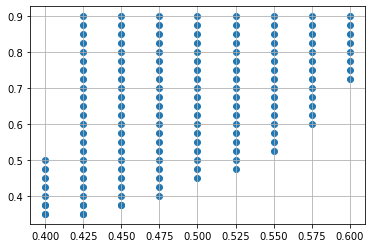

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [8]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'

In [9]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [10]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4000000000000001 0.3750000000000001
-------  14 0.4000000000000001 0.42500000000000016
-------  21 0.47500000000000014 0.4500000000000002
-------  28 0.5250000000000001 0.4750000000000002
-------  35 0.4250000000000001 0.5250000000000002
-------  42 0.4500000000000001 0.5500000000000003
-------  49 0.47500000000000014 0.5750000000000003
-------  56 0.5000000000000002 0.6000000000000003
-------  63 0.5000000000000002 0.6250000000000003
-------  70 0.5000000000000002 0.6500000000000004
-------  77 0.5000000000000002 0.6750000000000004
-------  84 0.5000000000000002 0.7000000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  98 0.47500000000000014 0.7500000000000004
-------  105 0.4500000000000001 0.7750000000000005
-------  112 0.4250000000000001 0.8000000000000005
-------  119 0.6000000000000003 0.8000000000000005
-------  126 0.5750000000000002 0.8250000000000005
-------  133 0.5500000000000003 0.8500000000

In [11]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140 147]


In [12]:
factor_iteration = 20.

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    weights_init[i] = cost.getParams()

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]
    
##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  7.003188894081856
RUN  2 , total integrated cost =  5.250596651485439
RUN  3 , total integrated cost =  2.067735804308177
RUN  4 , total integrated cost =  1.929159545856093
RUN  5 , total integrated cost =  1.4100896746964666
RUN  6 , total integrated cost =  1.341329001761508
RUN  7 , total integrated cost =  1.0782457495282656
RUN  8 , total integrated cost =  1.0305270413787375
RUN  9 , total integrated cost =  0.9283426126023451
RUN  10 , total integrated cost =  0.8874660131672122
RUN  1

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  35 , total integrated cost =  0.7052147203249354
Improved over  35  iterations in  13.901560984551907  seconds by  99.98805208142127  percent.
Problem in initial value trasfer:  sigmai_f 1.535448235174266 1.5288455877695173
Problem in initial value trasfer:  tau_inh 5.687351449251495 5.706949890961348
Problem in initial value trasfer:  Vmean_exc -56.62760069497415 -56.62760088668605
weight =  83696.58643141744
set cost params:  1.0 0.0 83696.58643141744
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5674.405746549682
Gradient descend method:  None
RUN  1 , total integrated cost =  4786.3491139907255
RUN  2 , total integrated cost =  4786.0233641210325
RUN  3 , total integrated cost =  4763.803192466239
RUN  4 , total integrated cost =  4751.136721905579
RUN  5 , total integrated cost =  4751.090900294898
RUN  6 , total integrated cost =  4751.085382347926
RUN  7 , total integrated cost =  4751.083587336287
RUN  8 , total in

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  4726.935350083213
RUN  20 , total integrated cost =  4726.935350083213
Control only changes marginally.
RUN  20 , total integrated cost =  4726.935350083213
Improved over  20  iterations in  2.055755291134119  seconds by  16.697262035633912  percent.
Problem in initial value trasfer:  sigmai_f 1.535448235174266 1.5322136026549933
Problem in initial value trasfer:  tau_inh 5.687351449251495 5.696952712653228
Problem in initial value trasfer:  Vmean_exc -56.62663796213849 -56.62664559883368
-------  7 0.4000000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5538.707762167343
Gradient descend method:  None
RUN  0 , total integrated cost =  5538.707762167343
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5538.707762167343
Gradient descend method:  None
RUN

...

RUN  18 , total integrated cost =  13.52334242671566
Control only changes marginally.
RUN  18 , total integrated cost =  13.52334242671566
Improved over  18  iterations in  2.8292598202824593  seconds by  99.94821011343033  percent.
Problem in initial value trasfer:  sigmai_f 1.516194542403302 1.515104839522287
Problem in initial value trasfer:  tau_inh 2.4543327010177 2.4544852594210416
Problem in initial value trasfer:  Vmean_exc -56.703536186497224 -56.703535767267915
weight =  19308.789152390396
set cost params:  1.0 0.0 19308.789152390396
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  25961.258239242798
Gradient descend method:  None
RUN  1 , total integrated cost =  25943.069790630667
RUN  2 , total integrated cost =  25943.069790630663


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  25943.069790630663
Control only changes marginally.
RUN  3 , total integrated cost =  25943.069790630663
Improved over  3  iterations in  1.6290936302393675  seconds by  0.07005996567855277  percent.
Problem in initial value trasfer:  sigmai_f 1.516194542403302 1.515104839522287
Problem in initial value trasfer:  tau_inh 2.4543327010177 2.4544852594210416
Problem in initial value trasfer:  Vmean_exc -56.703539357779114 -56.70353871241617
-------  35 0.4250000000000001 0.5250000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7978.317181785681
Gradient descend method:  None
RUN  0 , total integrated cost =  7978.317181785681
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7978.317181785681
Gradient descend method:  None
RUN  1 , total integrated cost =  7978.317181785681
Con

RUN  1 , total integrated cost =  19755.4958870387
Control only changes marginally.
RUN  1 , total integrated cost =  19755.4958870387
Improved over  1  iterations in  0.16677609831094742  seconds by  0.0  percent.
-------  91 0.5000000000000002 0.7250000000000004
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19611.738754959944
Gradient descend method:  None
RUN  0 , total integrated cost =  19611.738754959944
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19611.738754959944
Gradient descend method:  None
RUN  1 , total integrated cost =  19611.738754959944
Control only changes marginally.
RUN  1 , total integrated cost =  19611.738754959944
Improved over  1  iterations in  0.16092711314558983  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , t

RUN  1 , total integrated cost =  23532.636143093983
Control only changes marginally.
RUN  1 , total integrated cost =  23532.636143093983
Improved over  1  iterations in  0.1670392770320177  seconds by  0.0  percent.
-------  147 0.5000000000000002 0.9000000000000006
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18799.793834787204
Gradient descend method:  None
RUN  0 , total integrated cost =  18799.793834787204
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18799.793834787204
Gradient descend method:  None
RUN  1 , total integrated cost =  18799.793834787204
Control only changes marginally.
RUN  1 , total integrated cost =  18799.793834787204
Improved over  1  iterations in  0.152188990265131  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 ,

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


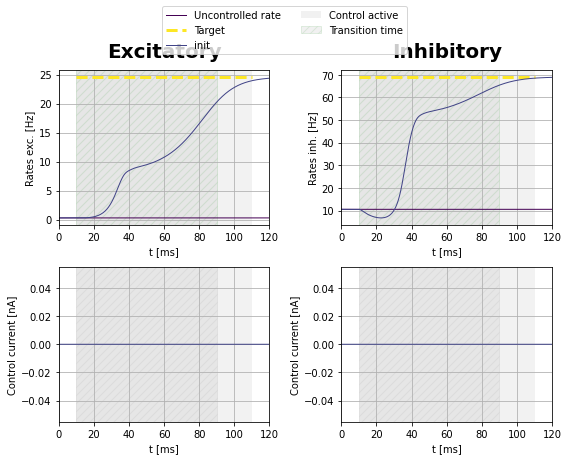

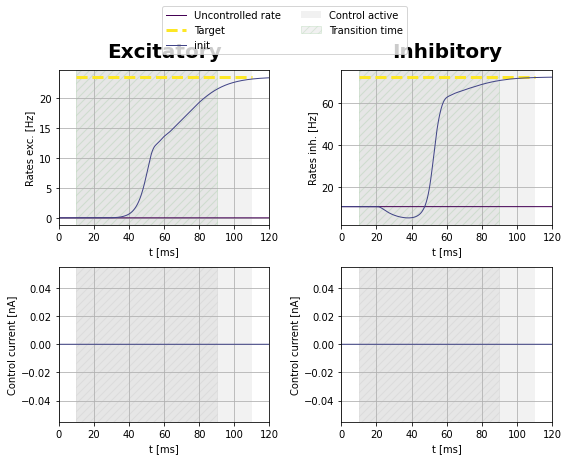

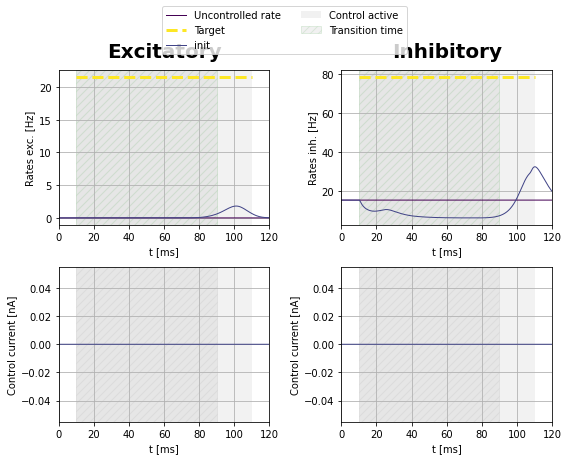

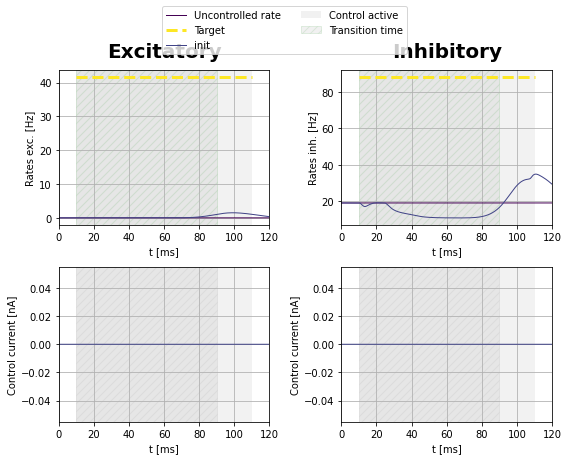

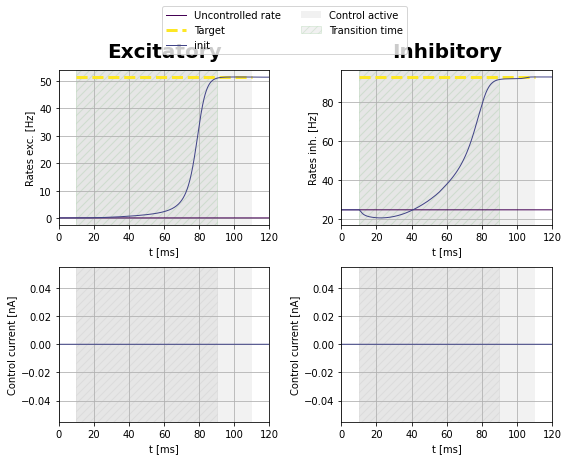

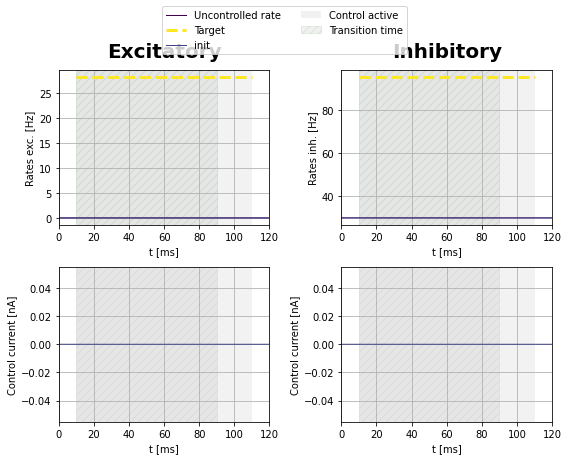

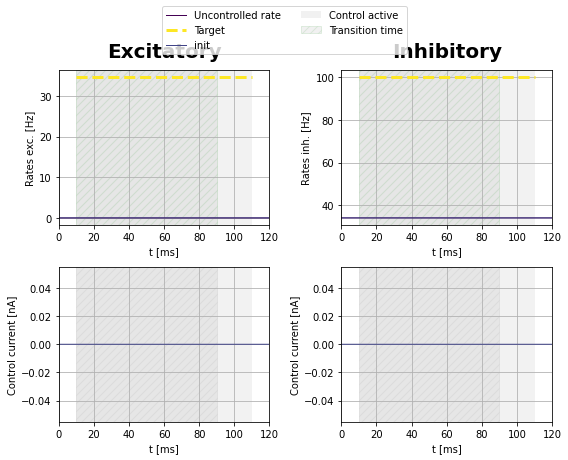

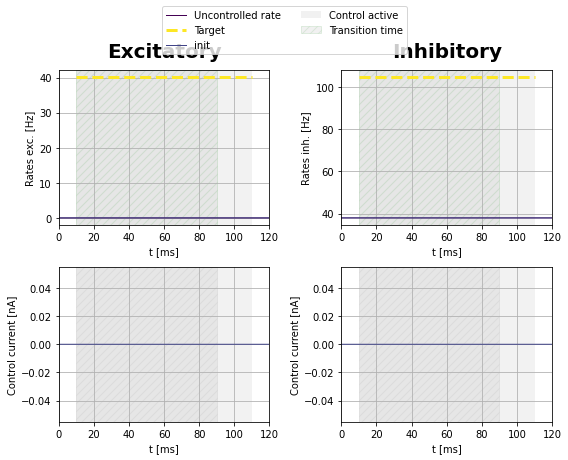

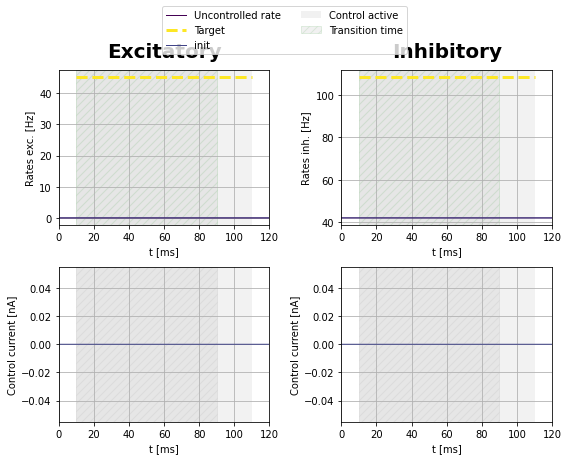

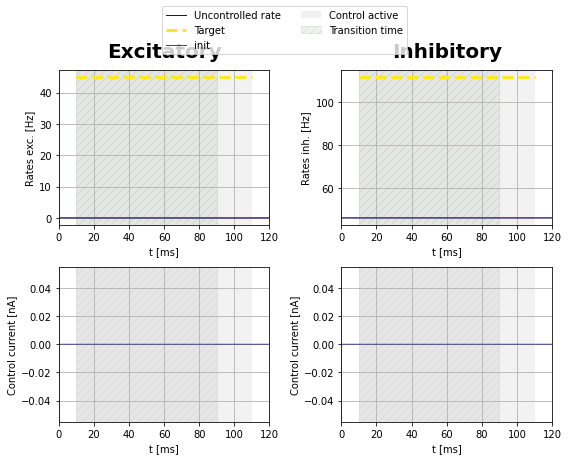

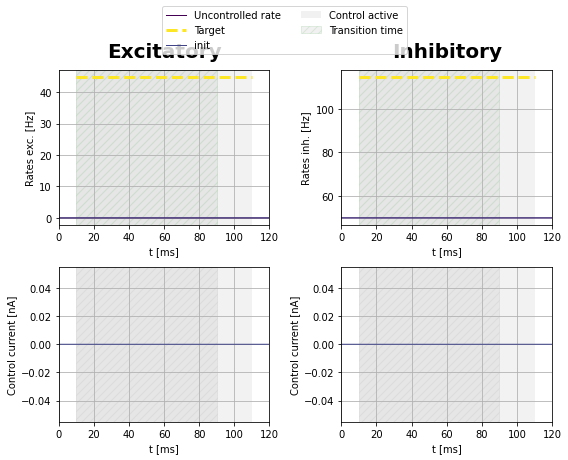

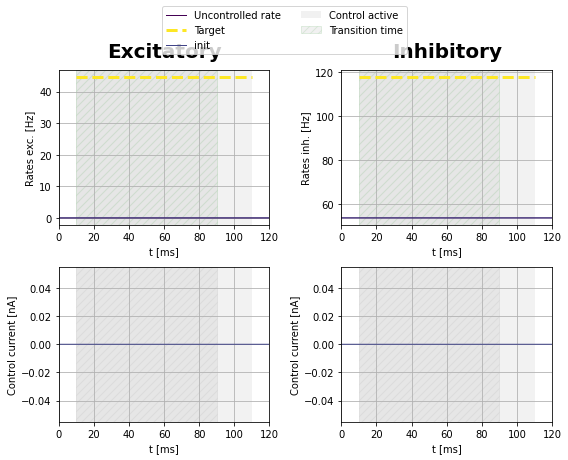

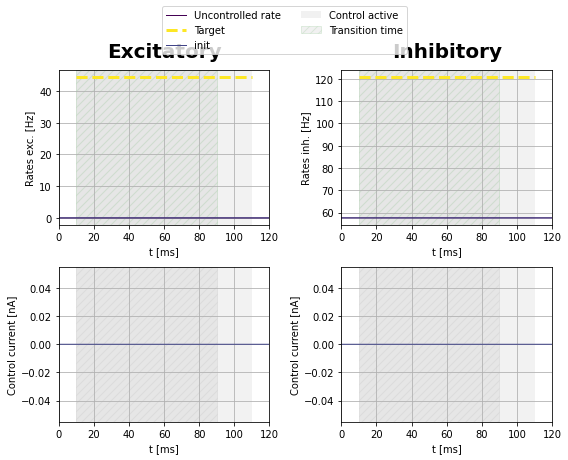

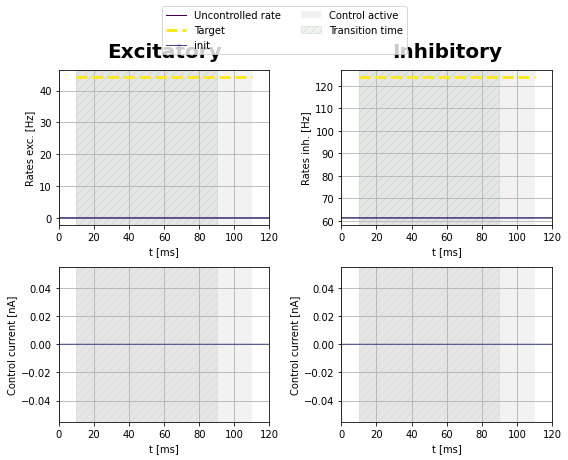

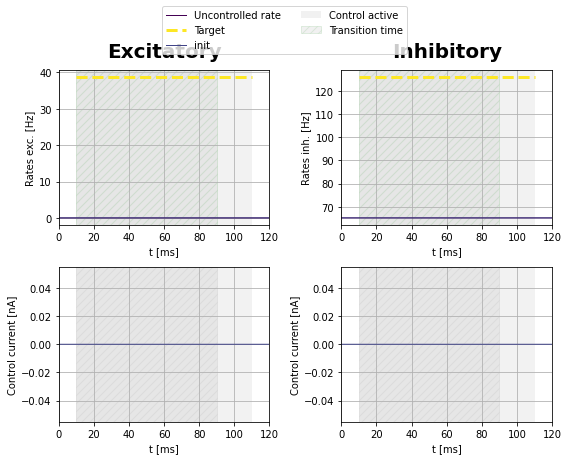

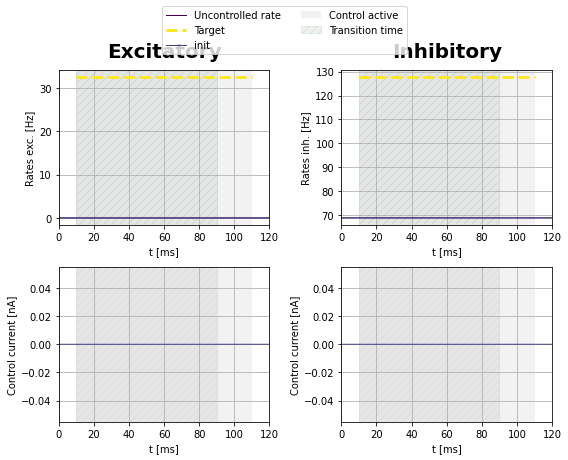

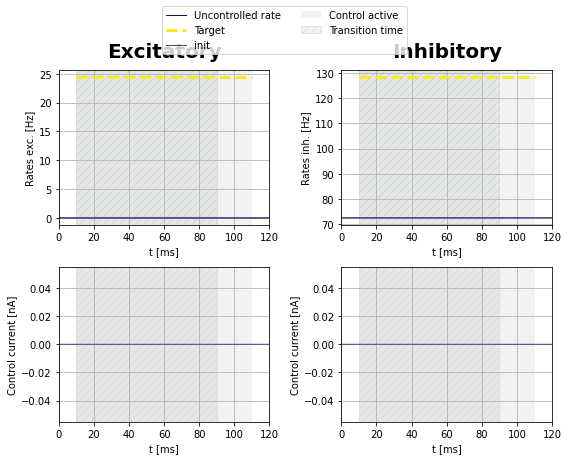

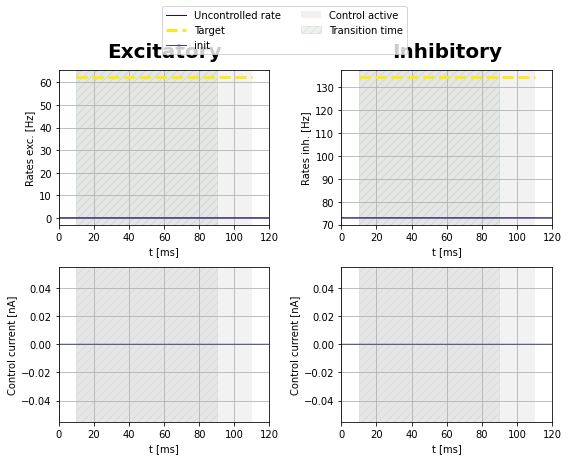

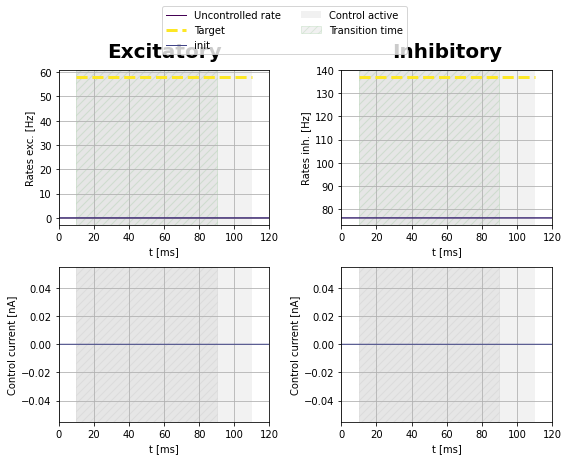

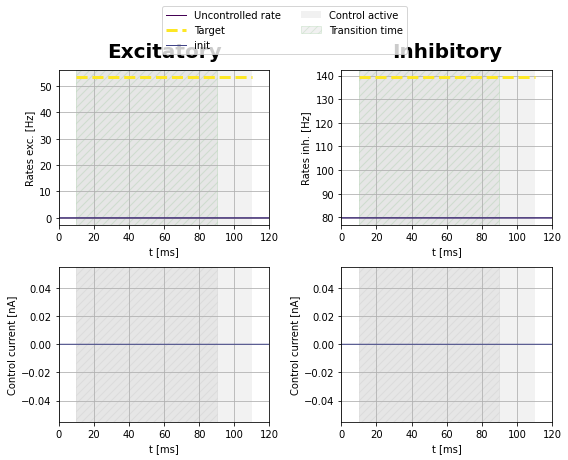

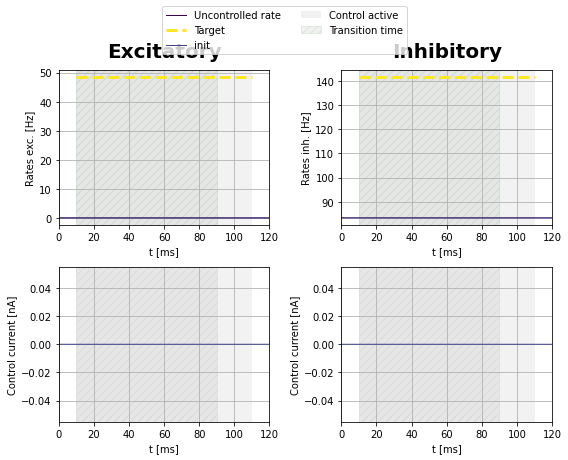

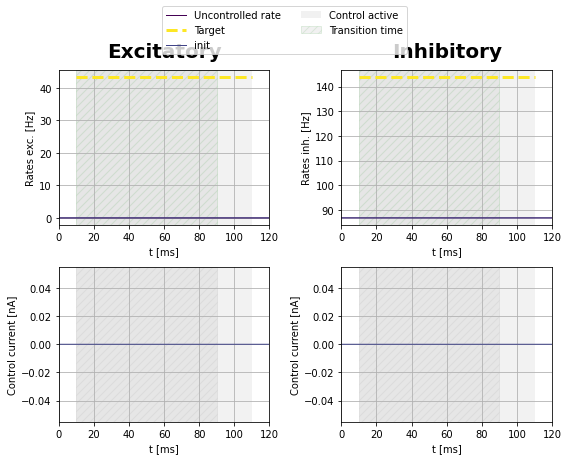

In [13]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [14]:
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    if np.abs(cost_uncontrolled[i] - costnode_init[i][0][0][0]) > 1.:
        continue
        
    print("no solution found for ", i)
    
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    if i != 0:
        control0 = bestControl_init[i-2*i_stepsize][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4000000000000001 0.3750000000000001
-------  14 0.4000000000000001 0.42500000000000016
-------  21 0.47500000000000014 0.4500000000000002
-------  28 0.5250000000000001 0.4750000000000002
-------  35 0.4250000000000001 0.5250000000000002
no solution found for  35
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7994.26768878728
Gradient descend method:  None
RUN  1 , total integrated cost =  7978.317361076817
RUN  2 , total integrated cost =  7978.317181801828
RUN  3 , total integrated cost =  7978.317181785681
RUN  4 , total integrated cost =  7978.317181785681
Control only changes marginally.
RUN  4 , total integrated cost =  7978.317181785681
Improved over  4  iterations in  0.5409425888210535  seconds by  0.19952430444594427  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7978.317181785681

RUN  1 , total integrated cost =  15011.243048171957
Control only changes marginally.
RUN  1 , total integrated cost =  15011.243048171957
Improved over  1  iterations in  0.1750611774623394  seconds by  0.0  percent.
-------  105 0.4500000000000001 0.7750000000000005
no solution found for  105
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10559.709248318897
Gradient descend method:  None
RUN  1 , total integrated cost =  10559.709248318897
Control only changes marginally.
RUN  1 , total integrated cost =  10559.709248318897
Improved over  1  iterations in  0.1943234484642744  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10559.709248318897
Gradient descend method:  None
RUN  1 , total integrated cost =  10559.709248318897
Control only changes marginally.
RUN  1 , total integrated cost =  10559.709248318897
Improved over  1  iteratio

In [15]:
for k in range(20):

    factor_iteration = 20

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  104508.84357851162
set cost params:  1.0 0.0 104508.84357851162
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5889.4458343551205
Gradient descend method:  None
RUN  1 , total integrated cost =  5888.263808701225
RUN  2 , total integrated cost =  5888.26319519991
RUN  3 , total integrated cost =  5888.263195105153
RUN  4 , total integrated cost =  5888.263195105133
RUN  5 , total integrated cost =  5888.263195105122


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  5888.263195105122
Control only changes marginally.
RUN  6 , total integrated cost =  5888.263195105122
Improved over  6  iterations in  1.4721491765230894  seconds by  0.020080654161048983  percent.
Problem in initial value trasfer:  sigmai_f 1.535448235174266 1.5322198058765981
Problem in initial value trasfer:  tau_inh 5.687351449251495 5.6969342998152275
Problem in initial value trasfer:  Vmean_exc -56.626552925820434 -56.626561347571595
-------  7 0.4000000000000001 0.3750000000000001
weight =  51050.91435625018
set cost params:  1.0 0.0 51050.91435625018
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5404.987651862865
Gradient descend method:  None
RUN  1 , total integrated cost =  5249.195966699951
RUN  2 , total integrated cost =  5248.675578676769
RUN  3 , total integrated cost =  5248.675578676754


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  5248.675578676754
Control only changes marginally.
RUN  4 , total integrated cost =  5248.675578676754
Improved over  4  iterations in  0.859235268086195  seconds by  2.89199686020072  percent.
Problem in initial value trasfer:  sigmae_f 1.5912640339566508 1.589696380366114
Problem in initial value trasfer:  tau_exc 19.154833285414583 19.169407639704573
Problem in initial value trasfer:  Vmean_exc -56.62523853111082 -56.62522794426732
-------  14 0.4000000000000001 0.42500000000000016
weight =  11.73414714409362
set cost params:  1.0 0.0 11.73414714409362
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4115.704447939073
Gradient descend method:  None


...

RUN  2 , total integrated cost =  28476.83104673663
Control only changes marginally.
RUN  2 , total integrated cost =  28476.83104673663
Improved over  2  iterations in  1.2280183397233486  seconds by  3.2961706978085203e-05  percent.
Problem in initial value trasfer:  sigmai_f 1.5001049725021276 1.5000470469053069
Problem in initial value trasfer:  tau_inh 0.5578497527961633 0.5578471943168919
Problem in initial value trasfer:  Vmean_exc -70.89019278092115 -70.89018930729729
-------  140 0.5250000000000001 0.8750000000000006
weight =  0.0
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.636143093983
Gradient descend method:  None
RUN  1 , total integrated cost =  23532.635802503744
 max iteration reached, step size =  1.2813331809171846e-143


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


 max iteration reached, step size =  1.2813331809171846e-143
RUN  2 , total integrated cost =  23532.635802503744
Control only changes marginally.
RUN  2 , total integrated cost =  23532.635802503744
Improved over  2  iterations in  1.3123186118900776  seconds by  1.4473101828116341e-06  percent.
Problem in initial value trasfer:  sigmai_f 1.5000835640686072 1.5000331312459922
Problem in initial value trasfer:  tau_inh 0.5244994467037025 0.5244948515503285
Problem in initial value trasfer:  Vmean_exc -73.59947666475787 -73.59947358981421
-------  147 0.5000000000000002 0.9000000000000006
weight =  0.0
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18799.793834787204
Gradient descend method:  None
RUN  1 , total integrated cost =  18799.793825579833
 max iteration reached, step size =  1.6401064715739963e-141


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


 max iteration reached, step size =  1.6401064715739963e-141
RUN  2 , total integrated cost =  18799.793825579833
Control only changes marginally.
RUN  2 , total integrated cost =  18799.793825579833
Improved over  2  iterations in  1.3370334301143885  seconds by  4.8975905997394875e-08  percent.
Problem in initial value trasfer:  sigmai_f 1.5000739692156908 1.5000297656945647
Problem in initial value trasfer:  Vmean_exc -76.28851607179628 -76.28851336422917


In [16]:
with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

In [17]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [18]:
factor_iteration = 20
    
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  62.88211142036393
Gradient descend method:  None
RUN  1 , total integrated cost =  0.5963443818099629
RUN  2 , total integrated cost =  0.5713156684297195
RUN  3 , total integrated cost =  0.551232460886495
RUN  4 , total integrated cost =  0.5352558602027546
RUN  5 , total integrated cost =  0.5254511469620518
RUN  6 , total integrated cost =  0.5172502206429451
RUN  7 , total integrated cost =  0.511411667603423
RUN  8 , total integrated cost =  0.5044515659838072
RUN  9 , total integrated cost =  0.4995156416864128
RUN  10 , total integrated cost =  0.4936965355344448
RUN  11 , total integrated cost =  0.48980810412262943
RUN  12 , total integrated cost =  0.48522937551200934
RUN  13 , total integrated cost =  0.48154654917880885
RUN  14 , total integrated cost =  0.47773418266168194
RUN  15 , total integrated cost =  0.4744920480918

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  628 , total integrated cost =  0.18072445605279108
Improved over  628  iterations in  52.45636795461178  seconds by  99.71259798379756  percent.
Problem in initial value trasfer:  Vmean_exc -56.62762162613306 -56.6276216000883
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.8000958913630154
Gradient descend method:  HS
RUN  1 , total integrated cost =  1.7943691891475362
RUN  2 , total integrated cost =  1.7925206050686509
RUN  3 , total integrated cost =  1.7914784446805165
RUN  4 , total integrated cost =  1.7894692504950882
RUN  5 , total integrated cost =  1.7892746961386237
RUN  6 , total integrated cost =  1.7892746961386234
RUN  7 , total integrated cost =  1.7892634197426591
RUN  8 , total integrated cost =  1.7879750276034707
RUN  9 , total integrated cost =  1.7841015767363853
RUN  10 , total integrated cost =  1.7837153844398916
RUN  11 , total integrated cost =  1.7

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  1.7817752521292147
Control only changes marginally.
RUN  15 , total integrated cost =  1.7817752521292147
Improved over  15  iterations in  4.8628635965287685  seconds by  1.0177590717085963  percent.
Problem in initial value trasfer:  Vmean_exc -56.62763409283787 -56.6276338862595
weight =  331264.4877311283
set cost params:  1.0 0.0 331264.4877311283
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5855.3211418658075
Gradient descend method:  None
RUN  1 , total integrated cost =  5356.719550252639
RUN  2 , total integrated cost =  5336.873980365689
RUN  3 , total integrated cost =  5319.344102502359
RUN  4 , total integrated cost =  5318.2763719674895
RUN  5 , total integrated cost =  5306.138994014404
RUN  6 , total integrated cost =  5297.928415822699
RUN  7 , total integrated cost =  5297.324382028919
RUN  8 , total integrated cost =  5269.776145038946
RUN  9 , total integrated cost =  5254.829069377671
RUN  10 , total int

...

Control only changes marginally.
RUN  154 , total integrated cost =  0.7177611934876229
Improved over  154  iterations in  27.620470026507974  seconds by  99.9961856892381  percent.
Problem in initial value trasfer:  tau_exc 21.757978132642656 21.757978152496943
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.170676955415718
Gradient descend method:  HS
RUN  1 , total integrated cost =  7.148056103439753
RUN  2 , total integrated cost =  7.134985900346641
RUN  3 , total integrated cost =  7.134977685001863
RUN  4 , total integrated cost =  7.1349632284373925
RUN  5 , total integrated cost =  7.134963220908105
RUN  6 , total integrated cost =  7.134963195488158
RUN  7 , total integrated cost =  7.134963195399656
RUN  8 , total integrated cost =  7.134963195338475
RUN  9 , total integrated cost =  7.13496319533799
RUN  10 , total integrated cost =  7.134963195337744
RUN  11 , total integrated cost =  7.13496319533771

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  7.134963195337712
Control only changes marginally.
RUN  12 , total integrated cost =  7.134963195337712
Improved over  12  iterations in  3.024973252788186  seconds by  0.49805283796857225  percent.
Problem in initial value trasfer:  tau_exc 21.757978132642656 21.757978152777255
Problem in initial value trasfer:  Vmean_exc -56.692006968436075 -56.69200683847914
weight =  263487.3084901095
set cost params:  1.0 0.0 263487.3084901095
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18727.600930309498
Gradient descend method:  None
RUN  1 , total integrated cost =  18138.55827767566
RUN  2 , total integrated cost =  18136.590610448227
RUN  3 , total integrated cost =  18136.349129792296
RUN  4 , total integrated cost =  18134.580387705268
RUN  5 , total integrated cost =  18127.091751561267
RUN  6 , total integrated cost =  18126.02867787555
RUN  7 , total integrated cost =  18125.817624739615
RUN  8 , total integrated cost =  1812

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  23 , total integrated cost =  17919.802034739467
Improved over  23  iterations in  5.898248240351677  seconds by  4.313413653868807  percent.
Problem in initial value trasfer:  tau_exc 21.757978132642656 21.75797815122123
Problem in initial value trasfer:  Vmean_exc -56.69193349756663 -56.69193556565491


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


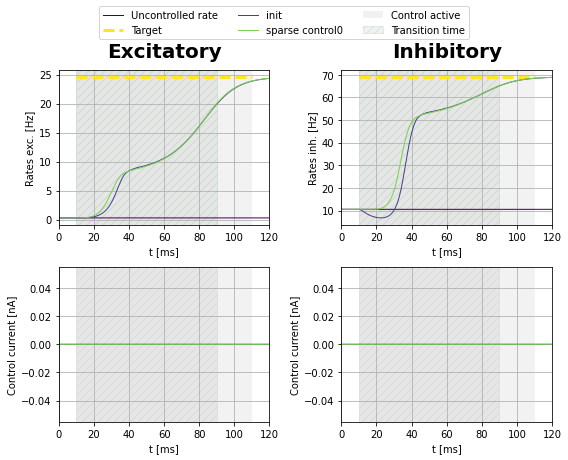

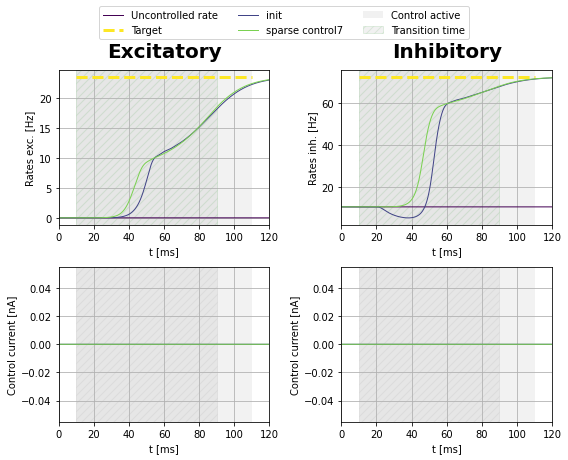

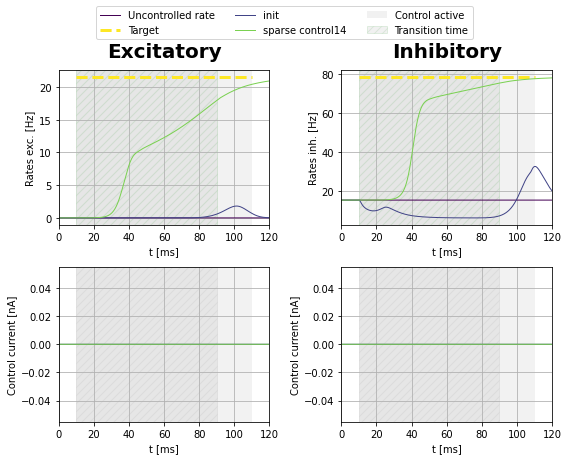

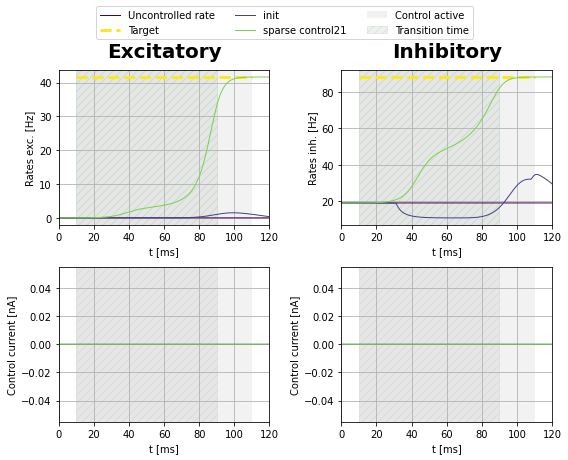

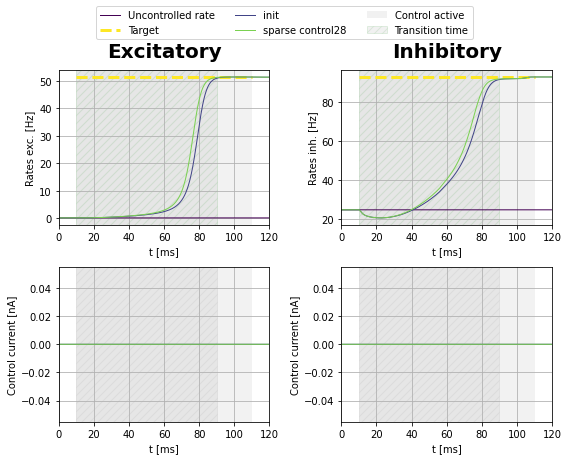

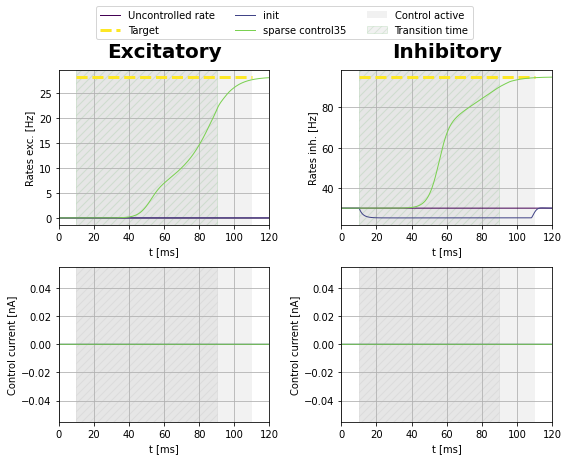

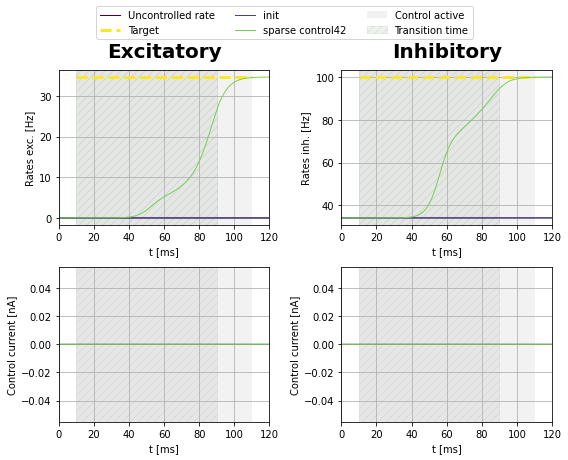

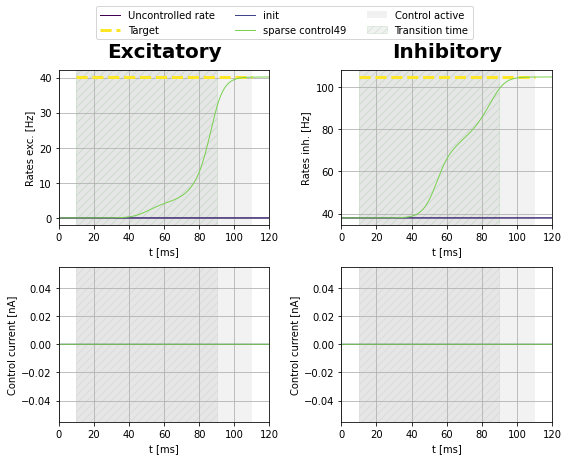

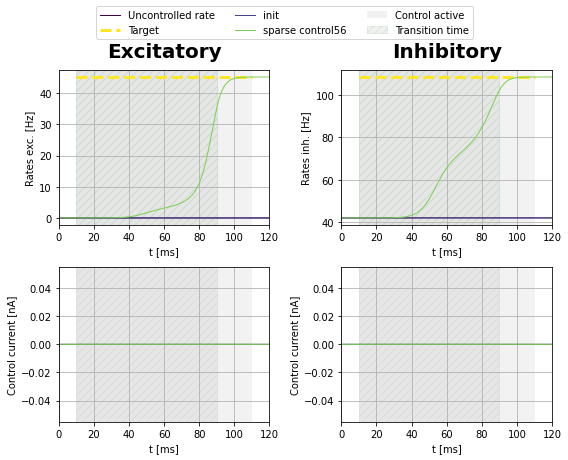

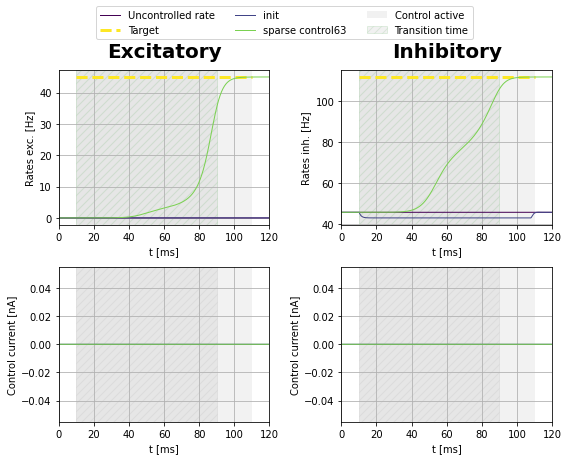

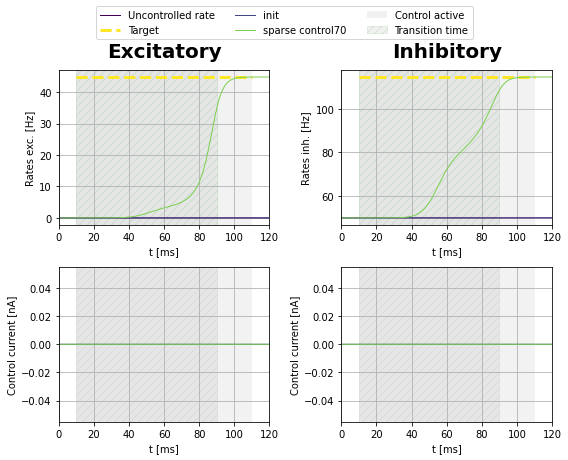

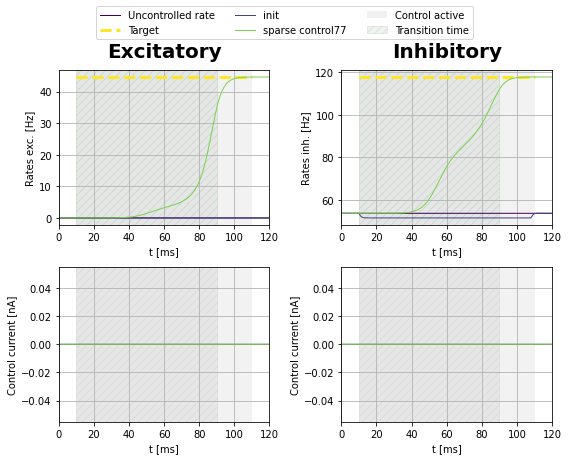

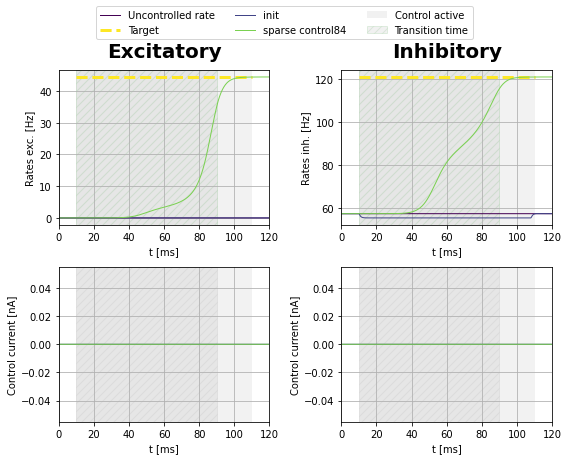

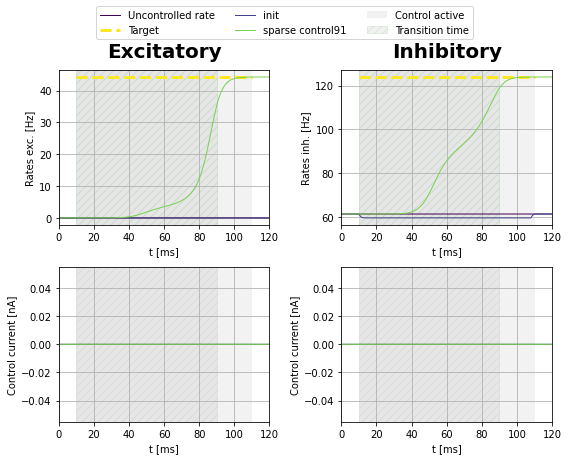

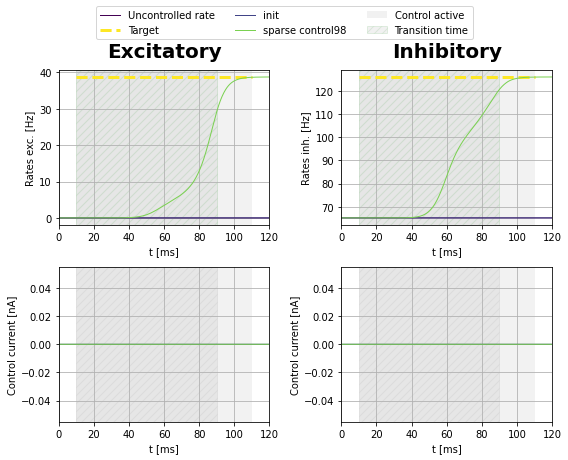

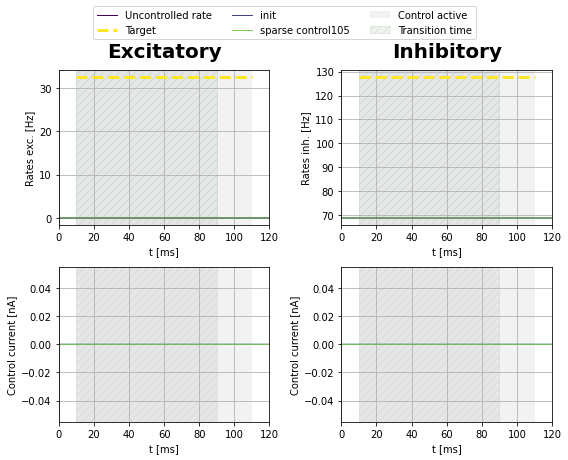

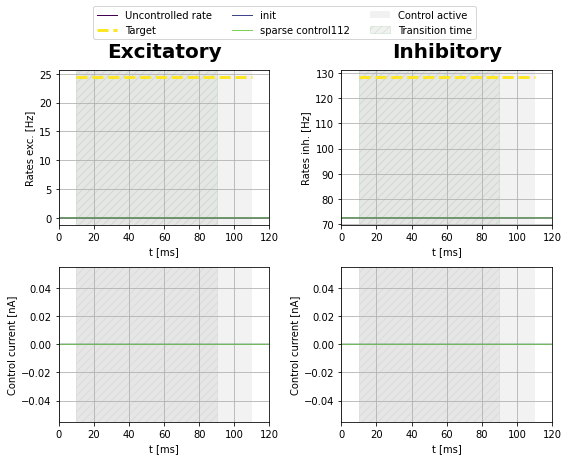

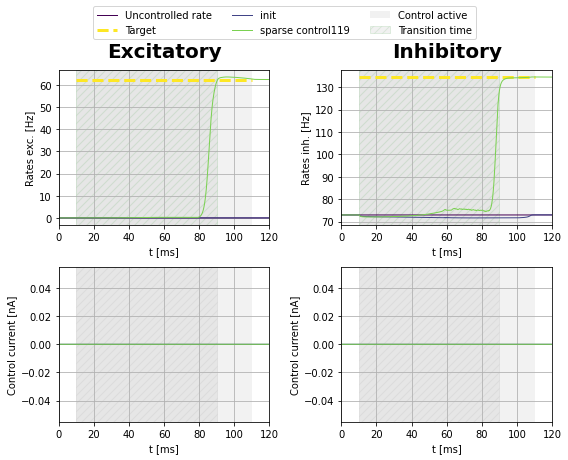

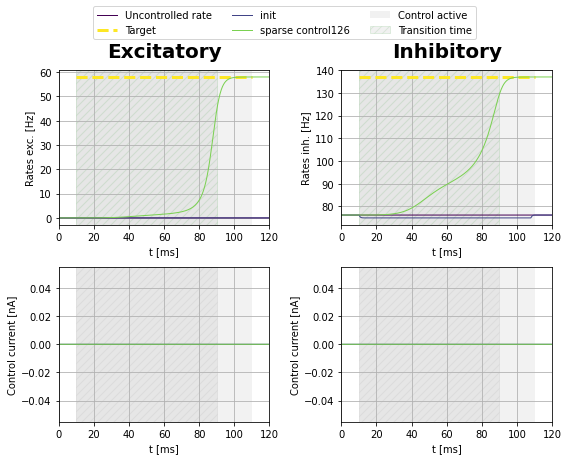

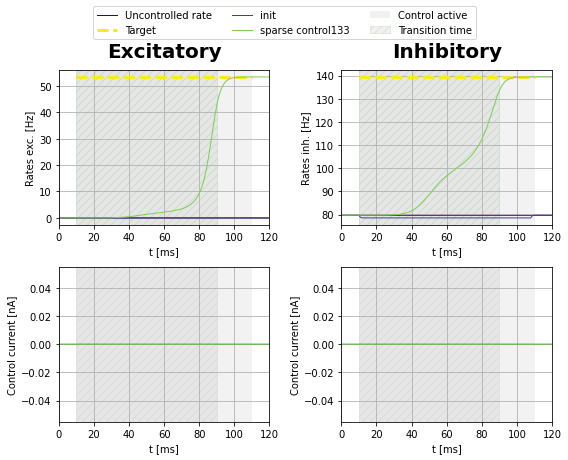

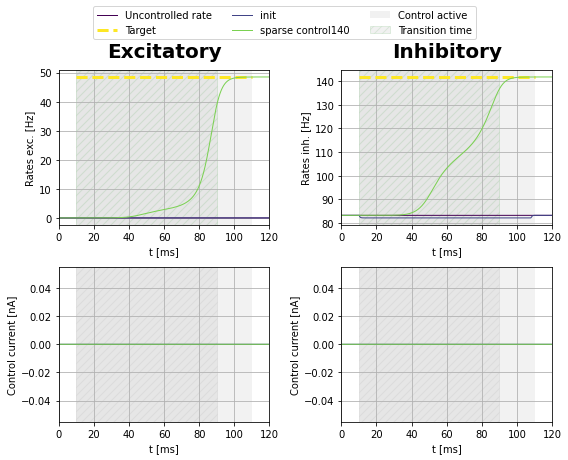

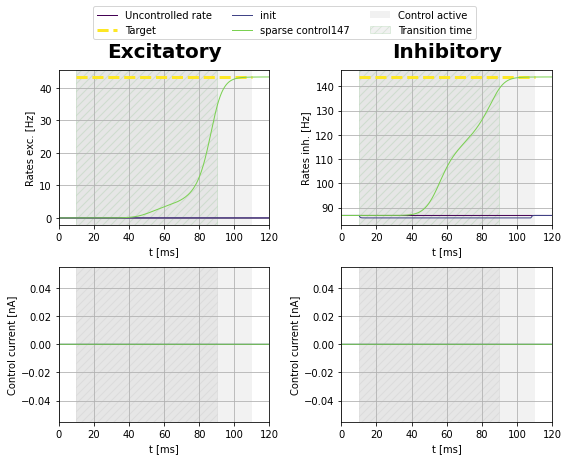

In [19]:
for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [20]:
factor_iteration = 20

for k in range(20):
    for i in i_range:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  373230.4268281536
set cost params:  1.0 0.0 373230.4268281536
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5895.033125718999
Gradient descend method:  None
RUN  1 , total integrated cost =  5894.726454484684
RUN  2 , total integrated cost =  5894.724735901775
RUN  3 , total integrated cost =  5894.72472098325
RUN  4 , total integrated cost =  5894.724720902984
RUN  5 , total integrated cost =  5894.724720902865
RUN  6 , total integrated cost =  5894.724720902847
RUN  7 , total integrated cost =  5894.724720902844


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  5894.724720902844
Control only changes marginally.
RUN  8 , total integrated cost =  5894.724720902844
Improved over  8  iterations in  2.378785140812397  seconds by  0.005231604463929784  percent.
Problem in initial value trasfer:  Vmean_exc -56.6265464178207 -56.62655488705779
-------  7 0.4000000000000001 0.3750000000000001
weight =  214263.14978615826
set cost params:  1.0 0.0 214263.14978615826
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5527.249715844361
Gradient descend method:  None
RUN  1 , total integrated cost =  5526.764933608231
RUN  2 , total integrated cost =  5526.76274597066
RUN  3 , total integrated cost =  5526.762682846863
RUN  4 , total integrated cost =  5526.762679481504
RUN  5 , total integrated cost =  5526.762679355207
RUN  6 , total integrated cost =  5526.762679349816
RUN  7 , total integrated cost =  5526.762679349525
RUN  8 , total integrated cost =  5526.762679349502
RUN  9 , total integrated c

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  5526.762679349486
Control only changes marginally.
RUN  12 , total integrated cost =  5526.762679349486
Improved over  12  iterations in  3.234992701560259  seconds by  0.008811552216997143  percent.
Problem in initial value trasfer:  Vmean_exc -56.62520322010517 -56.62519297627626
-------  14 0.4000000000000001 0.42500000000000016
weight =  81603.67990839001
set cost params:  1.0 0.0 81603.67990839001
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4639.806343649083
Gradient descend method:  None
RUN  1 , total integrated cost =  4639.785159754404
RUN  2 , total integrated cost =  4639.782937242292
RUN  3 , total integrated cost =  4639.782452321491
RUN  4 , total integrated cost =  4639.782349781881
RUN  5 , total integrated cost =  4639.782320122468
RUN  6 , total integrated cost =  4639.782311042897
RUN  7 , total integrated cost =  4639.782308136564
RUN  8 , total integrated cost =  4639.782307215942
RUN  9 , total integra

...

RUN  1 , total integrated cost =  28476.8076804243
Control only changes marginally.
RUN  1 , total integrated cost =  28476.8076804243
Improved over  1  iterations in  0.3768809363245964  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.5012074581886752 1.5012055885434852
Problem in initial value trasfer:  tau_exc 21.37565313828781 21.37566403717059
Problem in initial value trasfer:  Vmean_exc -56.704015568211766 -56.70401561081078
-------  140 0.5250000000000001 0.8750000000000006
weight =  483520.63292093517
set cost params:  1.0 0.0 483520.63292093517
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.5874738421
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23532.5874738421
Control only changes marginally.
RUN  1 , total integrated cost =  23532.5874738421
Improved over  1  iterations in  0.3461616486310959  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.501065940868336 1.5010658254616434
Problem in initial value trasfer:  tau_exc 21.62329444010742 21.623295001571567
Problem in initial value trasfer:  Vmean_exc -56.700665967132224 -56.70066635804714
-------  147 0.5000000000000002 0.9000000000000006
weight =  276489.5922225989
set cost params:  1.0 0.0 276489.5922225989
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18799.725840452626
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  18799.725840452626
Control only changes marginally.
RUN  1 , total integrated cost =  18799.725840452626
Improved over  1  iterations in  0.35866125486791134  seconds by  0.0  percent.
Problem in initial value trasfer:  tau_exc 21.757978132642656 21.7579781512175
Problem in initial value trasfer:  Vmean_exc -56.69193149859597 -56.691933625812894


In [21]:
with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)